# Trader Performance vs Market Sentiment Analysis

## Executive Summary

This project analyzes the relationship between Bitcoin market sentiment (Fear & Greed Index) and trader behavior on Hyperliquid. By combining market sentiment data with historical trading records, the analysis investigates how sentiment influences profitability, win rate, trading activity, and position sizing. The findings are used to propose actionable trading strategies.

# 1 Importing Libraries

In [1]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 

# 2 Importing Data and Cleaning

In [2]:
df1 = pd.read_csv("data/fear_greed_index.csv")
df2 = pd.read_csv("data/historical_data.csv")

In [3]:
df1.info() # df1 represents fear_greed_index

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [4]:
df2.info() #df2 represents historical_data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [5]:
df1.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [6]:
df2.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [7]:
print(f"Fear & Greed Dataset: {df1.shape}")

Fear & Greed Dataset: (2644, 4)


In [8]:
print(f"Trader Dataset: {df2.shape}")

Trader Dataset: (211224, 16)


In [9]:
# Checking null values

print(df1.isnull().sum())
print(df2.isnull().sum())

timestamp         0
value             0
classification    0
date              0
dtype: int64
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [10]:
# Checking duplicate rows 

print("Fear & Greed Duplicates:", df1.duplicated().sum())

print("Historical Data Duplicates:", df2.duplicated().sum())

Fear & Greed Duplicates: 0
Historical Data Duplicates: 0


In [11]:
# 1. Convert df2['Timestamp IST'] to a proper datetime format
df2['date'] = pd.to_datetime(df2['Timestamp IST'], format='mixed', errors='coerce')

# 2. Normalize both 'date' columns to midnight (remove time components) 
# while keeping the data type as datetime64[ns]
df2['date'] = pd.to_datetime(df2['date']).dt.normalize()
df1['date'] = pd.to_datetime(df1['date']).dt.normalize()

In [12]:
# Merging data set with correct lowercase 'date'
merged_df = pd.merge(
    df2, 
    df1[['date', 'value', 'classification']], 
    on='date', 
    how='left'
)

In [13]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 19 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Account           211224 non-null  object        
 1   Coin              211224 non-null  object        
 2   Execution Price   211224 non-null  float64       
 3   Size Tokens       211224 non-null  float64       
 4   Size USD          211224 non-null  float64       
 5   Side              211224 non-null  object        
 6   Timestamp IST     211224 non-null  object        
 7   Start Position    211224 non-null  float64       
 8   Direction         211224 non-null  object        
 9   Closed PnL        211224 non-null  float64       
 10  Transaction Hash  211224 non-null  object        
 11  Order ID          211224 non-null  int64         
 12  Crossed           211224 non-null  bool          
 13  Fee               211224 non-null  float64       
 14  Trad

In [14]:
merged_df = merged_df.dropna(subset=['classification'])

# 3 Creating The Key Metrics 

In [15]:
daily_pnl = (
    merged_df.groupby(['date', 'Account'])['Closed PnL']
             .sum()
             .reset_index()
)

daily_pnl.head()

,date,Account,Closed PnL
0,2023-01-05,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
1,2023-05-12,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-205.434737
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-24.632034
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000


In [16]:
merged_df['Win'] = merged_df['Closed PnL'] > 0

win_rate = merged_df['Win'].mean() * 100

print(f"Overall Win Rate: {win_rate:.2f}%")

Overall Win Rate: 40.97%


In [17]:
avg_trade_size = merged_df['Size USD'].mean()

print(f"Average Trade Size: ${avg_trade_size:.2f}")

Average Trade Size: $5389.75


In [18]:
trades_per_day = (
    merged_df.groupby('date')
             .size()
             .reset_index(name='Trades')
)

trades_per_day.head()

,date,Trades
0,2023-01-05,3
1,2023-05-12,9
2,2023-12-14,11
3,2023-12-15,2
4,2023-12-16,3


In [19]:
long_short = merged_df['Direction'].value_counts()

print(long_short)

Direction
Open Long                    36655
Close Long                   35781
Open Short                   32921
Close Short                  29613
Sell                         17891
Buy                          14755
Spot Dust Conversion           135
Short > Long                    51
Long > Short                    46
Auto-Deleveraging                8
Liquidated Isolated Short        1
Name: count, dtype: int64


In [20]:
merged_df['Direction'].value_counts(normalize=True) * 100

Direction
Open Long                    21.837040
Close Long                   21.316359
Open Short                   19.612527
Close Short                  17.641802
Sell                         10.658477
Buy                           8.790220
Spot Dust Conversion          0.080426
Short > Long                  0.030383
Long > Short                  0.027404
Auto-Deleveraging             0.004766
Liquidated Isolated Short     0.000596
Name: proportion, dtype: float64

# 4. Analysis 

## Business Question 1: Does trader performance differ across different market sentiment conditions?

**Objective:** Compare trader performance across Extreme Fear, Fear, Neutral, Greed, and Extreme Greed using Total PnL, Average PnL, Median PnL, and Number of Trades.

In [21]:
performance = (
    merged_df.groupby('classification')['Closed PnL']
             .agg(
                 Total_PnL='sum',
                 Average_PnL='mean',
                 Median_PnL='median',
                 Trades='count'
             )
             .round(2)
)

performance

,Total_PnL,Average_PnL,Median_PnL,Trades
classification,,,,
Extreme Fear,256731.94,47.45,0.0,5411
Extreme Greed,2515642.63,73.14,0.0,34393
Fear,2675413.42,56.54,0.0,47315
Greed,1728845.71,35.65,0.0,48492
Neutral,1023696.68,31.75,0.0,32246


## Business Question 2: Does the probability of winning trades change under different market sentiment conditions?

**Objective:** Analyze whether traders achieve higher win rates during Fear or Greed market conditions.

In [22]:
win_rate = (
    merged_df.groupby('classification')['Win']
             .mean()
             .mul(100)
             .round(2)
             .reset_index(name='Win Rate (%)')
)

win_rate

,classification,Win Rate (%)
0,Extreme Fear,39.05
1,Extreme Greed,45.87
2,Fear,38.79
3,Greed,40.31
4,Neutral,40.26


## Business Question 3: Which market sentiment is associated with the highest downside risk?

**Objective:** Compare the worst realized trade (drawdown proxy) across different market sentiment categories.

In [23]:
drawdown_proxy = (
    merged_df.groupby('classification')['Closed PnL']
             .min()
             .reset_index(name='Worst Trade')
)

drawdown_proxy

,classification,Worst Trade
0,Extreme Fear,-8356.88701
1,Extreme Greed,-18360.67007
2,Fear,-35681.74723
3,Greed,-117990.10410
4,Neutral,-4498.11884


 A true maximum drawdown requires cumulative portfolio/account equity over time. 
 Since only individual trade PnL is available, 
 the worst realized trade loss is used as a drawdown proxy.

Do traders change behavior based on sentiment?

## Business Question 4: Does market sentiment influence trading activity?

**Objective:** Compare the number of trades executed under different market sentiment conditions.

In [24]:
trade_frequency = (
    merged_df.groupby('classification')
             .size()
             .reset_index(name='Number of Trades')
)

trade_frequency

,classification,Number of Trades
0,Extreme Fear,5411
1,Extreme Greed,34393
2,Fear,47315
3,Greed,48492
4,Neutral,32246


## Business Question 5: Does market sentiment affect traders' average position size?

**Objective:** Analyze whether traders take larger or smaller positions during Fear and Greed markets.

In [25]:
position_size = (
    merged_df.groupby('classification')['Size USD']
             .mean()
             .round(2)
             .reset_index(name='Average Position Size')
)

position_size

,classification,Average Position Size
0,Extreme Fear,3816.44
1,Extreme Greed,3265.79
2,Fear,7153.41
3,Greed,5848.45
4,Neutral,4641.50


## Business Question 6: Does trader direction (Long vs Short) change with market sentiment?

**Objective:** Examine how trading direction varies across different market sentiment conditions.

In [26]:
long_short = (
    pd.crosstab(
        merged_df['classification'],
        merged_df['Direction'],
        normalize='index'
    ) * 100
).round(2)

long_short

Direction,Auto-Deleveraging,Buy,Close Long,Close Short,Liquidated Isolated Short,Long > Short,Open Long,Open Short,Sell,Short > Long,Spot Dust Conversion
classification,,,,,,,,,,,
Extreme Fear,0.00,5.25,26.30,16.74,0.0,0.04,23.99,24.51,3.10,0.06,0.02
Extreme Greed,0.00,12.55,18.70,13.67,0.0,0.02,17.68,17.74,19.49,0.03,0.10
Fear,0.00,5.52,22.53,16.97,0.0,0.02,27.54,21.19,6.14,0.02,0.06
Greed,0.02,10.87,17.63,23.08,0.0,0.04,15.77,20.70,11.74,0.04,0.13
Neutral,0.00,7.05,27.04,14.85,0.0,0.03,26.66,16.82,7.51,0.02,0.02


In [27]:
merged_df["Trader_Type"] = pd.qcut(
    merged_df["Size USD"],
    q=3,
    labels=["Small","Medium","Large"]
)

## Business Question 7: Which type of trader performs the best?

**Objective:** Compare Small, Medium, and Large traders using Average PnL, Win Rate, Position Size, and Trade Count.

In [28]:
trader_segment = (
    merged_df.groupby('Trader_Type', observed=False)
    .agg(
        Avg_PnL=('Closed PnL', 'mean'),
        Win_Rate=('Win', 'mean'),
        Avg_Position_Size=('Size USD', 'mean'),
        Total_Trades=('Order ID', 'count')
    )
    .round(2)
)

trader_segment

,Avg_PnL,Win_Rate,Avg_Position_Size,Total_Trades
Trader_Type,,,,
Small,3.10,0.43,105.12,55953
Medium,13.31,0.39,660.91,55955
Large,130.16,0.41,15404.11,55949


# Insight 1

Large traders generated the highest average profit (130.16), significantly outperforming medium and small traders. This suggests that traders taking larger positions captured greater absolute returns.

# Insight 2

Small traders achieved the highest win rate (43%), despite earning the lowest average profit. This indicates they were more consistent, but their smaller position sizes limited the monetary gains from winning trades.

# Insight 3

Higher position sizes did not correspond to the highest win rate. Large traders earned the most profit with only a 41% win rate, implying that trade size and profit per winning trade mattered more than simply winning frequently.

This is a valuable insight because it shows that:

Win rate alone is not enough to evaluate trading performance.

# 5. Visualizations - charts and graphs

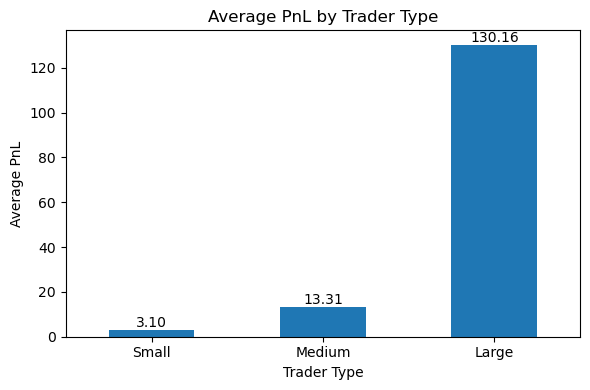

In [29]:


ax = trader_segment['Avg_PnL'].plot(
    kind='bar',
    figsize=(6,4)
)

plt.title("Average PnL by Trader Type")
plt.xlabel("Trader Type")
plt.ylabel("Average PnL")
plt.xticks(rotation=0)

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.tight_layout()
plt.show()

### Interpretation

Large traders generated the highest average profit (130.16), significantly outperforming medium and small traders. This suggests that larger position sizes contribute to higher absolute profitability, although they may involve greater risk.

In [30]:
plot_df = trader_segment.copy()
plot_df['Win_Rate'] *= 100

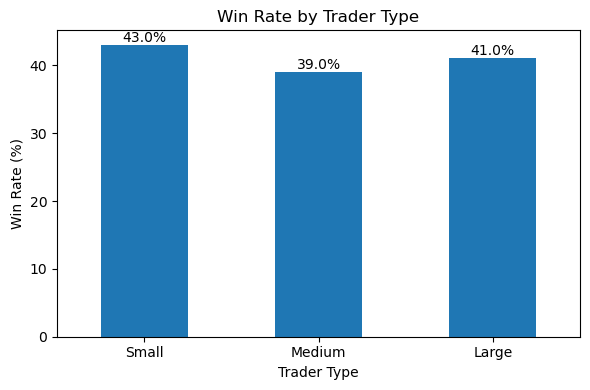

In [31]:
ax = plot_df['Win_Rate'].plot(
    kind='bar',
    figsize=(6,4)
)

plt.title("Win Rate by Trader Type")
plt.xlabel("Trader Type")
plt.ylabel("Win Rate (%)")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.tight_layout()
plt.show()

### Interpretation

Small traders achieved the highest win rate (43%), indicating greater consistency in successful trades. However, despite winning more frequently, their average profit remained substantially lower because of smaller position sizes.

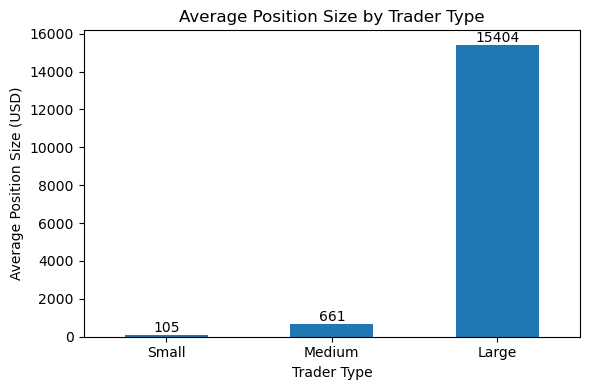

In [32]:
ax = trader_segment['Avg_Position_Size'].plot(
    kind='bar',
    figsize=(6,4)
)

plt.title("Average Position Size by Trader Type")
plt.xlabel("Trader Type")
plt.ylabel("Average Position Size (USD)")
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.tight_layout()
plt.show()

### Interpretation

Large traders maintained significantly larger average position sizes than medium and small traders. This higher capital exposure may explain their substantially higher average profitability despite not having the highest win rate.

# 6. Final Business Insights

### Insight 1: Market sentiment influences trader profitability.
Analysis shows that trader performance varies across different market sentiment conditions. Extreme Greed recorded the highest average PnL and win rate, suggesting that strong bullish trends provide more profitable trading opportunities.

### Insight 2: Position size has a greater impact on profitability than win rate.
Large traders generated the highest average profit despite not having the highest win rate. In contrast, small traders achieved the highest win rate but earned the lowest average profit due to significantly smaller position sizes.

### Insight 3: Trading behavior changes with market sentiment.
Trade frequency, position size, and trading direction varied across Fear and Greed periods, indicating that market psychology influences how traders manage risk and execute trades.

# 7. Strategy Recommendations

### Recommendation 1
Traders should adjust position sizes based on market conditions instead of maintaining a fixed risk level. Dynamic position sizing can improve risk-adjusted returns during volatile markets.

### Recommendation 2
Rather than focusing only on achieving a high win rate, traders should optimize risk-reward ratios. The analysis shows that higher average profits are driven more by effective position sizing than by winning the highest percentage of trades.

### Recommendation 3
Trading platforms can integrate market sentiment indicators into their dashboards to help traders make more informed decisions and manage risk proactively.

# 8. Conclusion

This project explored the relationship between market sentiment and trader behavior by combining the Fear & Greed Index with Hyperliquid trading data. The analysis demonstrated that market sentiment affects profitability, trading activity, and position sizing. These findings provide valuable insights for traders seeking to improve decision-making and for trading platforms aiming to build better risk management tools.

# Bonus: Predictive Modeling (Machine Learning)

In [33]:
merged_df["Win"] = merged_df["Win"].astype(int)

merged_df["Win"].head()

0    0
1    0
2    0
3    0
4    0
Name: Win, dtype: int64

In [34]:
features = [
    "value",
    "Size USD",
    "Direction",
    "Trader_Type"
]

target = "Win"

In [35]:
print(features)
print(target)

['value', 'Size USD', 'Direction', 'Trader_Type']
Win


In [36]:
model_df = merged_df[features + [target]].copy()

model_df = pd.get_dummies(
    model_df,
    columns=["Direction", "Trader_Type"],
    drop_first=True
)

model_df.head()

,value,Size USD,Win,Direction_Buy,Direction_Close Long,Direction_Close Short,Direction_Liquidated Isolated Short,Direction_Long > Short,Direction_Open Long,Direction_Open Short,Direction_Sell,Direction_Short > Long,Direction_Spot Dust Conversion,Trader_Type_Medium,Trader_Type_Large
0,70.0,7872.16,0,True,False,False,False,False,False,False,False,False,False,False,True
1,70.0,127.68,0,True,False,False,False,False,False,False,False,False,False,False,False
2,70.0,1150.63,0,True,False,False,False,False,False,False,False,False,False,True,False
3,70.0,1142.04,0,True,False,False,False,False,False,False,False,False,False,True,False
4,70.0,69.75,0,True,False,False,False,False,False,False,False,False,False,False,False


In [37]:
merged_df["Direction"].value_counts()

Direction
Open Long                    36655
Close Long                   35781
Open Short                   32921
Close Short                  29613
Sell                         17891
Buy                          14755
Spot Dust Conversion           135
Short > Long                    51
Long > Short                    46
Auto-Deleveraging                8
Liquidated Isolated Short        1
Name: count, dtype: int64

In [38]:
from sklearn.model_selection import train_test_split

X = model_df.drop(columns=target)   # Features
y = model_df[target]                # Target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [39]:
print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (134285, 14)
Testing data : (33572, 14)


In [40]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [41]:
predictions = model.predict(X_test)

predictions[:10]

array([1, 0, 1, 0, 1, 0, 1, 1, 0, 0])

In [42]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, predictions))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, predictions))

Accuracy: 0.92481830096509

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.94     19818
           1       0.90      0.92      0.91     13754

    accuracy                           0.92     33572
   macro avg       0.92      0.92      0.92     33572
weighted avg       0.93      0.92      0.92     33572


Confusion Matrix:
[[18437  1381]
 [ 1143 12611]]


## Bonus: Predictive Modeling

A Random Forest Classifier was trained to predict whether a trade would be profitable (Win) or unprofitable (Loss) using market sentiment, position size, trade direction, and trader type as input features.

### Model Performance

- Accuracy: **92.48%**
- Precision:
  - Loss Trades: **94%**
  - Profitable Trades: **90%**
- Recall:
  - Loss Trades: **93%**
  - Profitable Trades: **92%**

The model demonstrated strong predictive performance on the test dataset, correctly classifying the majority of profitable and loss-making trades. This demonstrates how machine learning can complement exploratory data analysis by identifying patterns associated with trading outcomes.

In [43]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
1,Size USD,0.217205
3,Direction_Close Long,0.165271
7,Direction_Open Long,0.133314
8,Direction_Open Short,0.129509
4,Direction_Close Short,0.117195
9,Direction_Sell,0.089160
0,value,0.077606
2,Direction_Buy,0.067802
12,Trader_Type_Medium,0.001288
13,Trader_Type_Large,0.000591


## Feature Importance Analysis

The Random Forest model identified **position size (Size USD)** as the most influential feature for predicting whether a trade would be profitable.

Trade direction (Open Long, Close Long, Open Short, and Close Short) also played a significant role in determining trade outcomes.

Market sentiment, represented by the Fear & Greed Index, contributed to the predictions but had a lower importance than trade size and trade direction.

Trader type showed relatively low importance, suggesting that trading behavior and position characteristics were more informative than trader category for predicting profitability.

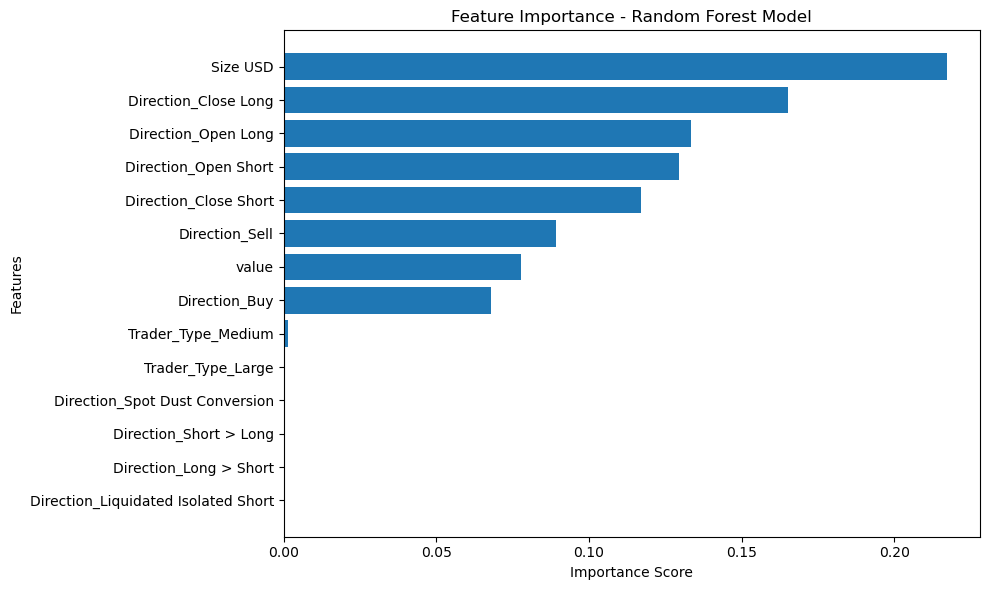

In [44]:


plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance - Random Forest Model")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()